In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../../../Data/Iris.csv",usecols=['SepalLengthCm','PetalLengthCm','Species'])
df

,SepalLengthCm,PetalLengthCm,Species
0,5.1,1.4,Iris-setosa
1,4.9,1.4,Iris-setosa
2,4.7,1.3,Iris-setosa
3,4.6,1.5,Iris-setosa
4,5.0,1.4,Iris-setosa
...,...,...,...
145,6.7,5.2,Iris-virginica
146,6.3,5.0,Iris-virginica
147,6.5,5.2,Iris-virginica
148,6.2,5.4,Iris-virginica


In [3]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df['Species'] = lb.fit_transform(df['Species'])
df

,SepalLengthCm,PetalLengthCm,Species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=2)

## 🔹 `penalty`

**Type:** `{'l1', 'l2', 'elasticnet', None}`
**Default:** `'l2'`

Specifies the norm of the penalty:

* `None` → No penalty is added
* `'l2'` → Adds L2 penalty term (**default**)
* `'l1'` → Adds L1 penalty term
* `'elasticnet'` → Adds both L1 and L2 penalties

---

## 🔹 `C`

**Type:** `float`
**Default:** `1.0`

Inverse of regularization strength:

* Smaller values → **stronger regularization**
* Larger values → **weaker regularization**
* `C = np.inf` → No regularization

---

## 🔹 `l1_ratio`

**Type:** `float`
**Default:** `0.0`

Elastic-Net mixing parameter (`0 ≤ l1_ratio ≤ 1`):

* `l1_ratio = 1` → Pure L1 penalty
* `l1_ratio = 0` → Pure L2 penalty
* Between `0` and `1` → Combination:

  ```
  l1_ratio * L1 + (1 - l1_ratio) * L2
  ```

---

## 🔹 `dual`

**Type:** `bool`
**Default:** `False`

* Chooses between **dual** or **primal** formulation
* Only supported for **L2 penalty with `liblinear` solver**
* Prefer `dual=False` when `n_samples > n_features`

---

## 🔹 `tol`

**Type:** `float`
**Default:** `1e-4`

Tolerance for stopping criteria.

---

## 🔹 `fit_intercept`

**Type:** `bool`
**Default:** `True`

* Whether to add a **bias (intercept)** term

---

## 🔹 `intercept_scaling`

**Type:** `float`
**Default:** `1`

Used only when:

* Solver = `liblinear`
* `fit_intercept = True`

Adds a synthetic feature:

```
x → [x, intercept_scaling]
```

Intercept becomes:

```
intercept_scaling × synthetic_feature_weight
```

---

## 🔹 `class_weight`

**Type:** `dict` or `'balanced'`
**Default:** `None`

* Custom weights:

  ```
  {class_label: weight}
  ```
* `'balanced'` mode:
  Automatically adjusts weights:

  ```
  n_samples / (n_classes * np.bincount(y))
  ```

> Note: Multiplied with `sample_weight` if provided.

---

## 🔹 `random_state`

**Type:** `int` or `RandomState`
**Default:** `None`

Used for reproducibility when using:

* `'sag'`
* `'saga'`
* `'liblinear'`

---

## 🔹 `solver`

**Type:** `{'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}`
**Default:** `'lbfgs'`

### Solver Guidelines:

* `'lbfgs'` → Good default for most problems
* `'liblinear'` → Good for small datasets (binary classification only)
* `'sag'`, `'saga'` → Faster for large datasets
* `'newton-cholesky'` → Good when:

  ```
  n_samples >> n_features * n_classes
  ```

  ⚠️ High memory usage (quadratic in features)

### Multiclass Notes:

* All solvers except `'liblinear'` support **multinomial loss**
* `'liblinear'` requires:

  ```
  OneVsRestClassifier
  ```

---

## 🔹 `max_iter`

**Type:** `int`
**Default:** `100`

Maximum number of iterations for convergence.

---

## 🔹 `verbose`

**Type:** `int`
**Default:** `0`

* Set > 0 for detailed logs
* Works with:

  * `'liblinear'`
  * `'lbfgs'`

---

## 🔹 `warm_start`

**Type:** `bool`
**Default:** `False`

* `True` → Reuse previous solution
* `False` → Start fresh

⚠️ Not useful for `liblinear`

---

## 🔹 `n_jobs`

**Type:** `int`
**Default:** `None`

* **No effect** in this context

---




In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lrClf = LogisticRegression()
lrClf.fit(X_train, y_train)
y_pred = lrClf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9666666666666667

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.88      0.93         8
           2       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

def multiClassMetrices(classifier):
    classifier.fit(X_train,y_train)
    y_pred = classifier.predict(X_test)
    print("Accuracy: ",accuracy_score(y_test, y_pred))
    
    print("--------------------Precision---------------- ")
    print("Precision: ", precision_score(y_test, y_pred, average=None))
    print("Precision Macro: ", precision_score(y_test, y_pred, average='macro'))
    print("Precision Weighted:", precision_score(y_test, y_pred, average='weighted') , "\n\n\n")
    
    print("--------------------Recall---------------- ")
    print("Recall: ", recall_score(y_test, y_pred, average=None))
    print("Recall Macro: ", recall_score(y_test, y_pred, average='macro'))
    print("Recall Weighted:", recall_score(y_test, y_pred, average='weighted'), "\n\n\n")
    
        
    print("--------------------F1 Score---------------- ")
    print("F1 Score: ", f1_score(y_test, y_pred, average=None))
    print("F1 Score Macro: ", f1_score(y_test, y_pred, average='macro'))
    print("F1 Score Weighted:", f1_score(y_test, y_pred, average='weighted') , "\n\n\n")
    
    print("Confusion Matrix: ")
    
    plt.figure(figsize=(12,12))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    

Accuracy:  0.9666666666666667
--------------------Precision---------------- 
Precision:  [1.         1.         0.88888889]
Precision Macro:  0.9629629629629629
Precision Weighted: 0.9703703703703703 



--------------------Recall---------------- 
Recall:  [1.    0.875 1.   ]
Recall Macro:  0.9583333333333334
Recall Weighted: 0.9666666666666667 



--------------------F1 Score---------------- 
F1 Score:  [1.         0.93333333 0.94117647]
F1 Score Macro:  0.9581699346405229
F1 Score Weighted: 0.9665359477124185 



Confusion Matrix: 


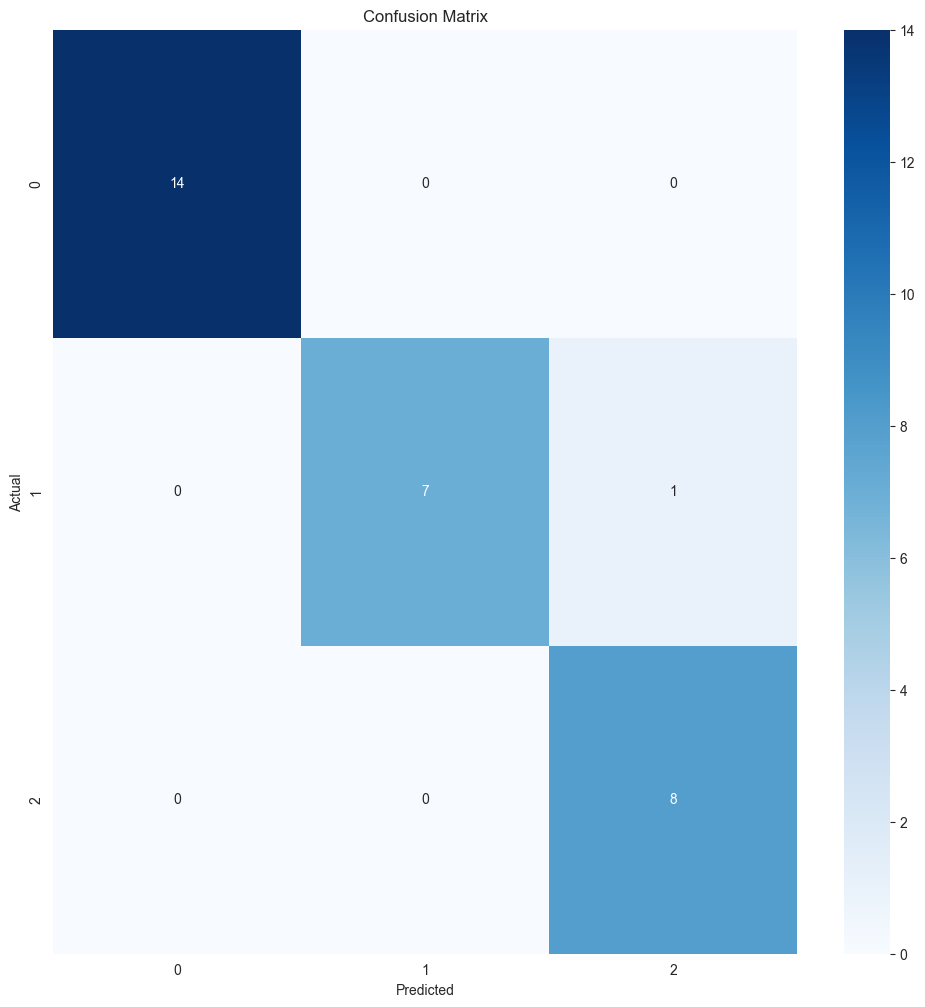

In [8]:
multiClassMetrices(LogisticRegression())

E:\MachineTrain_Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Softmax on Iris')

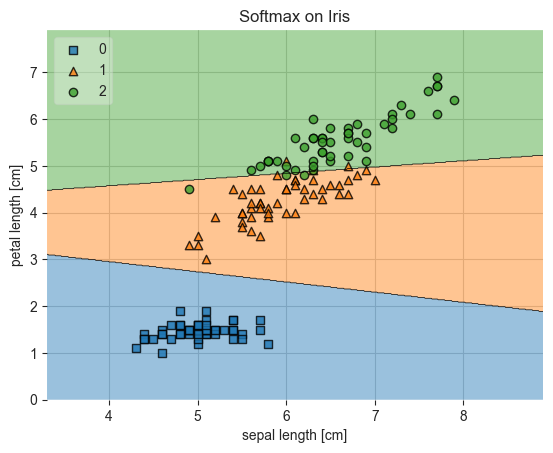

In [9]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(df.iloc[:,:-1].values, df.iloc[:,-1].values, lrClf, legend=2)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.title('Softmax on Iris')